# Dynamic GHZ Family: Experiment Setup

This notebook defines a scalable family of dynamic GHZ circuits and prepares utilities for upcoming experiments (single-path vs all-branches, runtime, memory, and pruning studies).

In [4]:
from pathlib import Path
import sys
from collections import Counter

CANDIDATES = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
REPO_ROOT = None
for candidate in CANDIDATES:
    if (candidate / "src").exists():
        REPO_ROOT = candidate.resolve()
        break
if REPO_ROOT is None:
    raise RuntimeError("Could not locate repository root containing 'src'.")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, qasm3
from qiskit.circuit.classical import expr

from src.utils.qasm3_to_ir import qasm3_to_circuit_ir


In [5]:
def create_constant_depth_dynamic_ghz(n_qubits: int, final_measure_all: bool = False) -> QuantumCircuit:
    """
    Build the dynamic constant-depth GHZ-style circuit.

    Pattern:
    1) H on even qubits
    2) CNOT fan-out from even qubits
    3) Mid-circuit measurements on odd qubits
    4) Conditional X corrections based on measurement logic
    5) Reset odd qubits
    6) Final CNOT layer
    7) Optional final measurements of all qubits
    """
    assert n_qubits >= 5 and n_qubits % 2 == 1, "n_qubits must be odd and >= 5"

    qr = QuantumRegister(n_qubits, "q")
    cr_branch = ClassicalRegister((n_qubits - 1) // 2, "cr1")

    if final_measure_all:
        cr_out = ClassicalRegister(n_qubits, "meas")
        qc = QuantumCircuit(qr, cr_branch, cr_out)
    else:
        qc = QuantumCircuit(qr, cr_branch)

    # Layer 1: H on even qubits
    for i in range(0, n_qubits, 2):
        qc.h(i)

    # Layer 2: CNOT fan-out from even qubits to neighbors
    for i in range(0, n_qubits - 1, 2):
        qc.cx(i, i + 1)
        if i > 0:
            qc.cx(i, i - 1)
    qc.cx(n_qubits - 1, n_qubits - 2)

    # Layer 3: measure odd qubits into branch register
    for i in range(1, n_qubits, 2):
        qc.measure(i, cr_branch[i // 2])

    # Layer 4: conditional corrections
    with qc.if_test((cr_branch[0], 1)):
        qc.x(2)

    for i in range(3, n_qubits - 1, 2):
        xor_expr = expr.lift(cr_branch[0])
        for j in range(1, i // 2 + 1):
            xor_expr = expr.bit_xor(cr_branch[j], xor_expr)
        with qc.if_test(xor_expr):
            qc.x(i + 1)

    # Layer 5: reset measured odd qubits
    for i in range(1, n_qubits, 2):
        qc.reset(i)

    # Layer 6: re-entangle odd qubits after reset
    for i in range(0, n_qubits - 1, 2):
        qc.cx(i, i + 1)

    # Layer 7: optional final readout
    if final_measure_all:
        for i in range(n_qubits):
            qc.measure(i, cr_out[i])

    return qc


def get_dynamic_ghz_family(min_qubits: int = 5, max_qubits: int = 21, final_measure_all: bool = True):
    assert min_qubits >= 5 and min_qubits % 2 == 1, "min_qubits must be odd and >= 5"
    assert max_qubits >= min_qubits and max_qubits % 2 == 1, "max_qubits must be odd and >= min_qubits"
    return [
        create_constant_depth_dynamic_ghz(n, final_measure_all=final_measure_all)
        for n in range(min_qubits, max_qubits + 1, 2)
    ]


def circuit_to_qasm3_text(qc: QuantumCircuit) -> str:
    return qasm3.dumps(qc)


def circuit_to_dynamic_ir(qc: QuantumCircuit):
    qasm_text = circuit_to_qasm3_text(qc)
    return qasm3_to_circuit_ir(
        qasm_text,
        apply_transpile=False,
        allow_dynamic=True,
    )


In [6]:
# Quick sanity check on a few sizes
sizes = [5, 7, 9]
circuits = [create_constant_depth_dynamic_ghz(n, final_measure_all=True) for n in sizes]

for qc in circuits:
    n = qc.num_qubits
    op_counts = qc.count_ops()
    print(f"n={n:2d} | depth={qc.depth():3d} | #clbits={qc.num_clbits:2d} | ops={dict(op_counts)}")


n= 5 | depth=  7 | #clbits= 7 | ops={'measure': 7, 'cx': 6, 'h': 3, 'if_else': 2, 'reset': 2}
n= 7 | depth=  8 | #clbits=10 | ops={'measure': 10, 'cx': 9, 'h': 4, 'if_else': 3, 'reset': 3}
n= 9 | depth=  9 | #clbits=13 | ops={'measure': 13, 'cx': 12, 'h': 5, 'if_else': 4, 'reset': 4}


In [7]:
# Preview OpenQASM 3 for the smallest instance
qc5 = create_constant_depth_dynamic_ghz(5, final_measure_all=True)
qasm_text_5 = circuit_to_qasm3_text(qc5)
print(qasm_text_5)


OPENQASM 3.0;
include "stdgates.inc";
bit[2] cr1;
bit[5] meas;
qubit[5] q;
h q[0];
h q[2];
h q[4];
cx q[0], q[1];
cx q[2], q[3];
cx q[2], q[1];
cx q[4], q[3];
cr1[0] = measure q[1];
cr1[1] = measure q[3];
if (cr1[0]) {
  x q[2];
}
if (cr1[1] ^ cr1[0]) {
  x q[4];
}
reset q[1];
reset q[3];
cx q[0], q[1];
cx q[2], q[3];
meas[0] = measure q[0];
meas[1] = measure q[1];
meas[2] = measure q[2];
meas[3] = measure q[3];
meas[4] = measure q[4];



In [8]:
# Convert one instance to CircuitIR and inspect operation composition
ir5 = circuit_to_dynamic_ir(qc5)
print(f"no_qubits={ir5.no_qubits}, no_clbits={ir5.no_clbits}, no_operations={len(ir5.operations)}")

ops = Counter(op.name.lower() for op in ir5.operations)
print(dict(sorted(ops.items(), key=lambda x: x[0])))


no_qubits=5, no_clbits=7, no_operations=20
{'cx': 6, 'h': 3, 'measure': 7, 'reset': 2, 'x': 2}


## Benchmark Configuration (Interactive + Cached)

In [9]:
import time
import csv
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib
from matplotlib.backends.backend_pgf import FigureCanvasPgf

from src.simulation import (
    DMRG_dynamic_single_path_from_circuit_ir,
    DMRG_dynamic_all_branches_from_circuit_ir,
)

matplotlib.backend_bases.register_backend("pgf", FigureCanvasPgf)

# -----------------------------
# Fixed benchmark choices
# -----------------------------
N_QUBITS_LIST = [5, 7, 9, 11, 13, 15, 17]
N_SHOTS_LIST = [1, 2, 4, 8, 16, 32, 64]
NUM_REPEATS = 10
COMPRESSION_STEPS = 25
NO_SWEEPS = 2
NETWORK_TYPE = "mps"
BOND_DIM = 4
FINAL_MEASURE_ALL = False
RANDOM_SEED_BASE = 20260416

# Test B subset shown in runtime/memory plots
COST_SHOT_SUBSET = [16, 32, 64]

# Test C (pruning sweep)
PRUNING_MAX_BRANCHES = [4, 8, 16, 32, 64]
PRUNING_PROBABILITY_CUTOFFS = [0.0]

# Execution controls
FORCE_RECOMPUTE = False    # set True to recompute everything from scratch
RUN_ORACLE = True
RUN_SINGLE_PATH = True
RUN_PRUNING = True

FIG_DIR = REPO_ROOT / "notebooks_for_paper" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR = REPO_ROOT / "notebooks_for_paper" / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)

CONFIG_TAG = (
    f"ghz_mps_bd{BOND_DIM}_cs{COMPRESSION_STEPS}_sw{NO_SWEEPS}"
    f"_fm{int(FINAL_MEASURE_ALL)}_R{NUM_REPEATS}"
    f"_n{'-'.join(str(x) for x in N_QUBITS_LIST)}"
)

def log(msg: str):
    print(f"[{datetime.now().strftime('%H:%M:%S')}] {msg}", flush=True)

log("Benchmark configuration loaded")
print("CONFIG_TAG:", CONFIG_TAG)
print("n_qubits:", N_QUBITS_LIST)
print("N_shots:", N_SHOTS_LIST)
print("R:", NUM_REPEATS)
print("Pruning max_branches:", PRUNING_MAX_BRANCHES)
print("Pruning cutoffs:", PRUNING_PROBABILITY_CUTOFFS)

[18:15:04] Benchmark configuration loaded
CONFIG_TAG: ghz_mps_bd4_cs25_sw2_fm0_R10_n5-7-9-11-13-15-17
n_qubits: [5, 7, 9, 11, 13, 15, 17]
N_shots: [1, 2, 4, 8, 16, 32, 64]
R: 10
Pruning max_branches: [4, 8, 16, 32, 64]
Pruning cutoffs: [0.0]


In [10]:
def mps_dims(n_qubits: int, bond_dim: int = 2):
    assert n_qubits >= 2
    return [int(bond_dim)] * (n_qubits - 1)


def bits_to_label(bits, expected_len=None):
    arr = [int(x) for x in bits]
    if expected_len is not None:
        arr = arr[:expected_len]
    return "".join(str(x) for x in arr)


def normalize_counts(counts, keys):
    total = float(sum(counts.get(k, 0) for k in keys))
    if total <= 0.0:
        return {k: 0.0 for k in keys}
    return {k: float(counts.get(k, 0)) / total for k in keys}


def tvd(p, q, keys):
    return 0.5 * sum(abs(float(p.get(k, 0.0)) - float(q.get(k, 0.0))) for k in keys)


def summarize_over_repeats(rows, n_qubits, n_shots):
    vals = [r for r in rows if int(r["n_qubits"]) == int(n_qubits) and int(r["n_shots"]) == int(n_shots)]
    out = {}
    for metric in ["tvd", "runtime_sec", "peak_bytes", "mean_fidelity"]:
        data = np.array([float(v[metric]) for v in vals], dtype=float)
        out[f"{metric}_mean"] = float(np.mean(data)) if data.size > 0 else np.nan
        out[f"{metric}_std"] = float(np.std(data, ddof=1)) if data.size > 1 else 0.0
    return out


def read_csv_rows(path):
    if not path.exists():
        return []
    with open(path, "r", newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))


def append_csv_row(path, row, fieldnames):
    write_header = not path.exists()
    with open(path, "a", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=fieldnames)
        if write_header:
            w.writeheader()
        w.writerow(row)


def overwrite_csv(path, rows, fieldnames):
    with open(path, "w", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=fieldnames)
        w.writeheader()
        for r in rows:
            w.writerow(r)


def repair_single_runs_csv_schema(path):
    """
    Repair legacy/mixed single-run CSV schema.
    Legacy rows have 7 columns (no config_tag), newer rows have 8 columns.
    This rewrites the file with a consistent 8-column header.
    """
    expected_fields = [
        "config_tag", "n_qubits", "n_shots", "repeat",
        "tvd", "runtime_sec", "peak_bytes", "mean_fidelity",
    ]

    if not path.exists():
        return

    with open(path, "r", newline="", encoding="utf-8") as f:
        raw_rows = list(csv.reader(f))

    if len(raw_rows) == 0:
        return

    header = raw_rows[0]
    data_rows = raw_rows[1:]

    needs_rewrite = header != expected_fields
    normalized = []

    for row in data_rows:
        if len(row) == 0:
            continue
        if len(row) == 8:
            rec = dict(zip(expected_fields, row))
        elif len(row) == 7:
            rec = {"config_tag": ""}
            rec.update(dict(zip(expected_fields[1:], row)))
            needs_rewrite = True
        else:
            needs_rewrite = True
            continue
        normalized.append(rec)

    if needs_rewrite:
        overwrite_csv(path, normalized, expected_fields)
        log(f"Repaired legacy schema in {path.name} (rows kept: {len(normalized)})")


def dedupe_single_path_rows(rows):
    """Keep one row per (n_qubits, n_shots, repeat), preferring the latest occurrence."""
    dedup = {}
    for r in rows:
        key = (int(r["n_qubits"]), int(r["n_shots"]), int(r["repeat"]))
        dedup[key] = r

    out = sorted(dedup.values(), key=lambda r: (int(r["n_qubits"]), int(r["n_shots"]), int(r["repeat"])))
    if len(out) != len(rows):
        log(f"Deduplicated single-path rows: {len(rows)} -> {len(out)}")
    return out


def parse_num(x):
    try:
        if x is None or x == "":
            return np.nan
        if "." in str(x) or "e" in str(x).lower():
            return float(x)
        return int(x)
    except Exception:
        return x




## Build GHZ Instances and Deterministic All-Branches Oracles (No Pruning)

In [25]:
oracle_csv = DATA_DIR / "ghz_all_branches_oracle.csv"
oracle_probs_csv = DATA_DIR / "ghz_all_branches_oracle_branch_probs.csv"

circuits = {}
ir_by_n = {}
expected_branch_keys_by_n = {}
for n in N_QUBITS_LIST:
    qc = create_constant_depth_dynamic_ghz(n, final_measure_all=FINAL_MEASURE_ALL)
    circuits[n] = qc
    ir_by_n[n] = circuit_to_dynamic_ir(qc)
    m = (n - 1) // 2
    expected_branch_keys_by_n[n] = [format(x, f"0{m}b") for x in range(2**m)]

all_branches_oracle = {}
all_branches_rows = []

existing_oracle_rows = [r for r in read_csv_rows(oracle_csv) if r.get("config_tag") == CONFIG_TAG]
existing_prob_rows = [r for r in read_csv_rows(oracle_probs_csv) if r.get("config_tag") == CONFIG_TAG]

if RUN_ORACLE and (FORCE_RECOMPUTE or len(existing_oracle_rows) < len(N_QUBITS_LIST) or len(existing_prob_rows) == 0):
    log("Computing all-branches oracles (no pruning) ...")

    # remove old rows for this config
    keep_oracle = [r for r in read_csv_rows(oracle_csv) if r.get("config_tag") != CONFIG_TAG]
    keep_probs = [r for r in read_csv_rows(oracle_probs_csv) if r.get("config_tag") != CONFIG_TAG]

    computed_oracle_rows = []
    computed_prob_rows = []

    for idx, n in enumerate(N_QUBITS_LIST, start=1):
        log(f"[Oracle {idx}/{len(N_QUBITS_LIST)}] Start n={n}")
        ir = ir_by_n[n]
        D_n = mps_dims(n, BOND_DIM)
        branch_keys = expected_branch_keys_by_n[n]

        t0 = time.perf_counter()
        fidelity, branches, memory_stats = DMRG_dynamic_all_branches_from_circuit_ir(
            compression_steps=COMPRESSION_STEPS,
            no_sweeps=NO_SWEEPS,
            D=D_n,
            network_structure=[n],
            circuit_ir=ir,
            network_type=NETWORK_TYPE,
            max_branches=None,
            probability_cutoff=0.0,
            max_pruning_error=None,
            return_branches=True,
            return_state=False,
            return_bra=False,
            return_classical_bits=True,
            return_pruning_error=False,
            return_memory_stats=True,
        )
        runtime = time.perf_counter() - t0

        probs = {k: 0.0 for k in branch_keys}
        for b in branches:
            label = bits_to_label(b["classical_bits"], expected_len=(n - 1)//2)
            probs[label] += float(b["probability"])

        row = {
            "config_tag": CONFIG_TAG,
            "n_qubits": int(n),
            "fidelity": float(fidelity),
            "runtime_sec": float(runtime),
            "peak_bytes": int(memory_stats["peak_bytes_estimate"]),
            "final_bytes": int(memory_stats["final_bytes_estimate"]),
            "num_expected_branches": int(len(branch_keys)),
            "num_recovered_branches": int(sum(1 for v in probs.values() if v > 1e-15)),
        }
        computed_oracle_rows.append(row)

        for label in branch_keys:
            computed_prob_rows.append({
                "config_tag": CONFIG_TAG,
                "n_qubits": int(n),
                "branch_label": label,
                "probability": float(probs[label]),
            })

        log(f"[Oracle {idx}/{len(N_QUBITS_LIST)}] Done n={n} | branches={row['num_recovered_branches']}/{row['num_expected_branches']} | runtime={runtime:.3f}s")

    overwrite_csv(
        oracle_csv,
        keep_oracle + computed_oracle_rows,
        ["config_tag", "n_qubits", "fidelity", "runtime_sec", "peak_bytes", "final_bytes", "num_expected_branches", "num_recovered_branches"],
    )
    overwrite_csv(
        oracle_probs_csv,
        keep_probs + computed_prob_rows,
        ["config_tag", "n_qubits", "branch_label", "probability"],
    )
    log(f"Saved oracle CSVs: {oracle_csv.name}, {oracle_probs_csv.name}")

# load oracle data for this config
existing_oracle_rows = [r for r in read_csv_rows(oracle_csv) if r.get("config_tag") == CONFIG_TAG]
existing_prob_rows = [r for r in read_csv_rows(oracle_probs_csv) if r.get("config_tag") == CONFIG_TAG]

for n in N_QUBITS_LIST:
    branch_keys = expected_branch_keys_by_n[n]
    probs = {k: 0.0 for k in branch_keys}
    for r in existing_prob_rows:
        if int(r["n_qubits"]) == int(n):
            probs[str(r["branch_label"])] = float(r["probability"])

    row = next((r for r in existing_oracle_rows if int(r["n_qubits"]) == int(n)), None)
    assert row is not None, f"Missing oracle row for n={n}. Set RUN_ORACLE=True and rerun this cell."

    all_branches_oracle[n] = {
        "fidelity": float(row["fidelity"]),
        "runtime_sec": float(row["runtime_sec"]),
        "peak_bytes": int(float(row["peak_bytes"])),
        "final_bytes": int(float(row["final_bytes"])),
        "num_expected_branches": int(float(row["num_expected_branches"])),
        "num_recovered_branches": int(float(row["num_recovered_branches"])),
        "probs": probs,
    }

all_branches_rows = [{
    "n_qubits": int(n),
    "fidelity": all_branches_oracle[n]["fidelity"],
    "runtime_sec": all_branches_oracle[n]["runtime_sec"],
    "peak_bytes": all_branches_oracle[n]["peak_bytes"],
    "final_bytes": all_branches_oracle[n]["final_bytes"],
    "num_expected_branches": all_branches_oracle[n]["num_expected_branches"],
    "num_recovered_branches": all_branches_oracle[n]["num_recovered_branches"],
} for n in N_QUBITS_LIST]

log("Oracle data loaded and ready")
for row in all_branches_rows:
    print(row)

[22:52:30] Computing all-branches oracles (no pruning) ...
[22:52:30] [Oracle 1/7] Start n=5


/Users/innocenzo/anaconda3/envs/qiskit_cutting/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[22:52:32] [Oracle 1/7] Done n=5 | branches=4/4 | runtime=2.077s
[22:52:32] [Oracle 2/7] Start n=7
[22:52:36] [Oracle 2/7] Done n=7 | branches=8/8 | runtime=3.977s
[22:52:36] [Oracle 3/7] Start n=9
[22:52:46] [Oracle 3/7] Done n=9 | branches=16/16 | runtime=10.343s
[22:52:46] [Oracle 4/7] Start n=11
[22:53:10] [Oracle 4/7] Done n=11 | branches=32/32 | runtime=24.214s
[22:53:10] [Oracle 5/7] Start n=13
[22:54:09] [Oracle 5/7] Done n=13 | branches=64/64 | runtime=59.339s
[22:54:09] [Oracle 6/7] Start n=15
[22:56:38] [Oracle 6/7] Done n=15 | branches=128/128 | runtime=148.938s
[22:56:38] [Oracle 7/7] Start n=17
[23:02:59] [Oracle 7/7] Done n=17 | branches=256/256 | runtime=380.609s
[23:02:59] Saved oracle CSVs: ghz_all_branches_oracle.csv, ghz_all_branches_oracle_branch_probs.csv
[23:02:59] Oracle data loaded and ready
{'n_qubits': 5, 'fidelity': 0.5000000002, 'runtime_sec': 2.0770998329971917, 'peak_bytes': 4096, 'final_bytes': 4096, 'num_expected_branches': 4, 'num_recovered_branches': 

## Single-Path Sweep (Test A + Test B, With Progress and Resume)

In [26]:
single_csv = DATA_DIR / "ghz_single_path_runs.csv"

single_fields = [
    "config_tag", "n_qubits", "n_shots", "repeat",
    "tvd", "runtime_sec", "peak_bytes", "mean_fidelity",
]

repair_single_runs_csv_schema(single_csv)

existing_single = [r for r in read_csv_rows(single_csv) if r.get("config_tag") == CONFIG_TAG]
for r in existing_single:
    r["n_qubits"] = int(r["n_qubits"])
    r["n_shots"] = int(r["n_shots"])
    r["repeat"] = int(r["repeat"])
existing_single = dedupe_single_path_rows(existing_single)
completed_keys = {(int(r["n_qubits"]), int(r["n_shots"]), int(r["repeat"])) for r in existing_single}

if RUN_SINGLE_PATH:
    total_tasks = len(N_QUBITS_LIST) * len(N_SHOTS_LIST) * NUM_REPEATS
    done = len(completed_keys)
    log(f"Single-path tasks already completed from cache: {done}/{total_tasks}")

    rng_master = np.random.default_rng(RANDOM_SEED_BASE)

    # advance RNG deterministically for reproducibility in resume mode
    # by replaying all previous shot draws
    # we map each task to deterministic sub-seeds without consuming global RNG in skipped tasks
    task_seed_rng = np.random.default_rng(RANDOM_SEED_BASE + 999)

    task_list = []
    for n in N_QUBITS_LIST:
        for N in N_SHOTS_LIST:
            for rep in range(NUM_REPEATS):
                task_list.append((n, N, rep))

    for task_idx, (n, N, rep) in enumerate(task_list, start=1):
        task_key = (n, N, rep)
        # deterministic seed for this task
        base_task_seed = int(task_seed_rng.integers(0, 2**32 - 1, dtype=np.uint32))

        if task_key in completed_keys and not FORCE_RECOMPUTE:
            continue

        ir = ir_by_n[n]
        D_n = mps_dims(n, BOND_DIM)
        m = (n - 1) // 2
        branch_keys = expected_branch_keys_by_n[n]
        oracle_probs = all_branches_oracle[n]["probs"]

        counts = {k: 0 for k in branch_keys}
        total_runtime = 0.0
        peak_bytes = 0
        fidelity_values = []

        shot_rng = np.random.default_rng(base_task_seed)

        t_task = time.perf_counter()
        for _ in range(N):
            seed = int(shot_rng.integers(0, 2**32 - 1, dtype=np.uint32))

            t0 = time.perf_counter()
            fidelity, classical_bits, memory_stats = DMRG_dynamic_single_path_from_circuit_ir(
                compression_steps=COMPRESSION_STEPS,
                no_sweeps=NO_SWEEPS,
                D=D_n,
                network_structure=[n],
                circuit_ir=ir,
                network_type=NETWORK_TYPE,
                seed=seed,
                return_state=False,
                return_bra=False,
                return_classical_bits=True,
                return_branch_probability=False,
                n_samples_final=None,
                return_counts=False,
                return_shots=False,
                return_memory_stats=True,
            )
            elapsed = time.perf_counter() - t0

            label = bits_to_label(classical_bits, expected_len=m)
            counts[label] += 1

            total_runtime += float(elapsed)
            peak_bytes = max(peak_bytes, int(memory_stats["peak_bytes_estimate"]))
            fidelity_values.append(float(fidelity))

        empirical_probs = normalize_counts(counts, branch_keys)
        tvd_val = tvd(empirical_probs, oracle_probs, branch_keys)

        row = {
            "config_tag": CONFIG_TAG,
            "n_qubits": int(n),
            "n_shots": int(N),
            "repeat": int(rep),
            "tvd": float(tvd_val),
            "runtime_sec": float(total_runtime),
            "peak_bytes": int(peak_bytes),
            "mean_fidelity": float(np.mean(np.array(fidelity_values, dtype=float))),
        }
        append_csv_row(single_csv, row, single_fields)

        dt = time.perf_counter() - t_task
        done += 1
        log(f"[Single {done}/{total_tasks}] Completed n={n}, N={N}, rep={rep} | TVD={tvd_val:.6f} | task_time={dt:.2f}s")

repair_single_runs_csv_schema(single_csv)

single_path_rows = [r for r in read_csv_rows(single_csv) if r.get("config_tag") == CONFIG_TAG]
for r in single_path_rows:
    r["n_qubits"] = int(r["n_qubits"])
    r["n_shots"] = int(r["n_shots"])
    r["repeat"] = int(r["repeat"])
    r["tvd"] = float(r["tvd"])
    r["runtime_sec"] = float(r["runtime_sec"])
    r["peak_bytes"] = int(float(r["peak_bytes"]))
    r["mean_fidelity"] = float(r["mean_fidelity"])
single_path_rows = dedupe_single_path_rows(single_path_rows)

log(f"Single-path rows available for this config: {len(single_path_rows)}")




[23:02:59] Single-path tasks already completed from cache: 0/490
[23:03:00] [Single 1/490] Completed n=5, N=1, rep=0 | TVD=0.750000 | task_time=0.52s
[23:03:00] [Single 2/490] Completed n=5, N=1, rep=1 | TVD=0.750000 | task_time=0.47s
[23:03:01] [Single 3/490] Completed n=5, N=1, rep=2 | TVD=0.750000 | task_time=0.49s
[23:03:01] [Single 4/490] Completed n=5, N=1, rep=3 | TVD=0.750000 | task_time=0.37s
[23:03:01] [Single 5/490] Completed n=5, N=1, rep=4 | TVD=0.750000 | task_time=0.48s
[23:03:02] [Single 6/490] Completed n=5, N=1, rep=5 | TVD=0.750000 | task_time=0.47s
[23:03:02] [Single 7/490] Completed n=5, N=1, rep=6 | TVD=0.750000 | task_time=0.38s
[23:03:03] [Single 8/490] Completed n=5, N=1, rep=7 | TVD=0.750000 | task_time=0.49s
[23:03:03] [Single 9/490] Completed n=5, N=1, rep=8 | TVD=0.750000 | task_time=0.69s
[23:03:04] [Single 10/490] Completed n=5, N=1, rep=9 | TVD=0.750000 | task_time=0.53s
[23:03:05] [Single 11/490] Completed n=5, N=2, rep=0 | TVD=0.500000 | task_time=1.18

## Aggregate Single-Path Results and Save CSV

In [11]:
agg_csv = DATA_DIR / "ghz_single_path_aggregated.csv"
single_csv = DATA_DIR / "ghz_single_path_runs.csv"

# Make this cell robust after kernel restarts or partial execution order.
if ("single_path_rows" not in globals()) or (len(single_path_rows) == 0):
    repair_single_runs_csv_schema(single_csv)
    single_path_rows = [r for r in read_csv_rows(single_csv) if r.get("config_tag") == CONFIG_TAG]
    for r in single_path_rows:
        r["n_qubits"] = int(r["n_qubits"])
        r["n_shots"] = int(r["n_shots"])
        r["repeat"] = int(r["repeat"])
        r["tvd"] = float(r["tvd"])
        r["runtime_sec"] = float(r["runtime_sec"])
        r["peak_bytes"] = int(float(r["peak_bytes"]))
        r["mean_fidelity"] = float(r["mean_fidelity"])
    single_path_rows = dedupe_single_path_rows(single_path_rows)

if len(single_path_rows) > 0:
    aggregated_rows = []
    for n in N_QUBITS_LIST:
        for N in N_SHOTS_LIST:
            s = summarize_over_repeats(single_path_rows, n_qubits=n, n_shots=N)
            aggregated_rows.append({
                "config_tag": CONFIG_TAG,
                "n_qubits": int(n),
                "n_shots": int(N),
                **s,
            })

    # merge with other configs
    prev = [r for r in read_csv_rows(agg_csv) if r.get("config_tag") != CONFIG_TAG]
    out_rows = prev + aggregated_rows

    fields = [
        "config_tag", "n_qubits", "n_shots",
        "tvd_mean", "tvd_std",
        "runtime_sec_mean", "runtime_sec_std",
        "peak_bytes_mean", "peak_bytes_std",
        "mean_fidelity_mean", "mean_fidelity_std",
    ]
    overwrite_csv(agg_csv, out_rows, fields)

    log(f"Saved aggregated single-path CSV: {agg_csv.name}")
    print("Sample aggregated rows:")
    for r in aggregated_rows[:5]:
        print(r)
else:
    # Fallback: if single-path cache is absent for this tag, use aggregated cache directly.
    aggregated_rows = [r for r in read_csv_rows(agg_csv) if r.get("config_tag") == CONFIG_TAG]
    for r in aggregated_rows:
        r["n_qubits"] = int(r["n_qubits"])
        r["n_shots"] = int(r["n_shots"])
        for k in ["tvd_mean", "tvd_std", "runtime_sec_mean", "runtime_sec_std", "peak_bytes_mean", "peak_bytes_std", "mean_fidelity_mean", "mean_fidelity_std"]:
            r[k] = float(r[k])

    if len(aggregated_rows) > 0:
        log(f"No single-path rows for current tag; using cached aggregated rows from {agg_csv.name}")
    else:
        all_single_rows = read_csv_rows(single_csv)
        available_tags = sorted(set(r.get("config_tag", "") for r in all_single_rows))
        raise RuntimeError(
            "No single-path or aggregated rows available for current CONFIG_TAG. "
            f"CONFIG_TAG={CONFIG_TAG}. Available tags in single CSV: {available_tags}"
        )



RuntimeError: No single-path or aggregated rows available for current CONFIG_TAG. CONFIG_TAG=ghz_mps_bd4_cs25_sw2_fm0_R10_n5-7-9-11-13-15-17. Available tags in single CSV: ['ghz_mps_bd2_cs25_sw2_fm0_R10_n5-7-11-13-15-17', 'ghz_mps_bd2_cs25_sw2_fm0_R10_n5-7-9-11-13-15-17']

## Test C: Pruning Sweep (All-Branches)

In [32]:
pruning_csv = DATA_DIR / "ghz_pruning_runs.csv"
pruning_fields = [
    "config_tag", "n_qubits", "max_branches", "probability_cutoff",
    "tvd_to_oracle", "runtime_sec", "peak_bytes", "final_bytes",
    "pruning_error_bound", "num_recovered_branches", "mean_branch_fidelity",
]

existing_pruning = [r for r in read_csv_rows(pruning_csv) if r.get("config_tag") == CONFIG_TAG]
completed_pruning_keys = {
    (int(r["n_qubits"]), int(r["max_branches"]), float(r["probability_cutoff"]))
    for r in existing_pruning
}

if RUN_PRUNING:
    total_tasks = len(N_QUBITS_LIST) * len(PRUNING_MAX_BRANCHES) * len(PRUNING_PROBABILITY_CUTOFFS)
    done = len(completed_pruning_keys)
    log(f"Pruning tasks already completed from cache: {done}/{total_tasks}")

    for n in N_QUBITS_LIST:
        ir = ir_by_n[n]
        D_n = mps_dims(n, BOND_DIM)
        m = (n - 1) // 2
        branch_keys = expected_branch_keys_by_n[n]
        oracle_probs = all_branches_oracle[n]["probs"]

        for max_br in PRUNING_MAX_BRANCHES:
            for cutoff in PRUNING_PROBABILITY_CUTOFFS:
                k = (int(n), int(max_br), float(cutoff))
                if k in completed_pruning_keys and not FORCE_RECOMPUTE:
                    continue

                t0 = time.perf_counter()
                fidelity, pruning_error, branches, memory_stats = DMRG_dynamic_all_branches_from_circuit_ir(
                    compression_steps=COMPRESSION_STEPS,
                    no_sweeps=NO_SWEEPS,
                    D=D_n,
                    network_structure=[n],
                    circuit_ir=ir,
                    network_type=NETWORK_TYPE,
                    max_branches=int(max_br),
                    probability_cutoff=float(cutoff),
                    max_pruning_error=None,
                    return_pruning_error=True,
                    return_branches=True,
                    return_state=False,
                    return_bra=False,
                    return_classical_bits=True,
                    return_memory_stats=True,
                )
                runtime = time.perf_counter() - t0

                probs = {k2: 0.0 for k2 in branch_keys}
                branch_fids = []
                for b in branches:
                    label = bits_to_label(b["classical_bits"], expected_len=m)
                    probs[label] += float(b["probability"])
                    branch_fids.append(float(b.get("branch_fidelity", 1.0)))

                tvd_val = tvd(probs, oracle_probs, branch_keys)

                row = {
                    "config_tag": CONFIG_TAG,
                    "n_qubits": int(n),
                    "max_branches": int(max_br),
                    "probability_cutoff": float(cutoff),
                    "tvd_to_oracle": float(tvd_val),
                    "runtime_sec": float(runtime),
                    "peak_bytes": int(memory_stats["peak_bytes_estimate"]),
                    "final_bytes": int(memory_stats["final_bytes_estimate"]),
                    "pruning_error_bound": float(pruning_error),
                    "num_recovered_branches": int(sum(1 for v in probs.values() if v > 1e-15)),
                    "mean_branch_fidelity": float(np.mean(np.array(branch_fids, dtype=float))) if len(branch_fids) > 0 else 0.0,
                }
                append_csv_row(pruning_csv, row, pruning_fields)
                done += 1
                log(f"[Pruning {done}/{total_tasks}] n={n}, max_br={max_br}, cutoff={cutoff} | TVD={tvd_val:.6f} | runtime={runtime:.3f}s")

pruning_rows = [r for r in read_csv_rows(pruning_csv) if r.get("config_tag") == CONFIG_TAG]
for r in pruning_rows:
    r["n_qubits"] = int(r["n_qubits"])
    r["max_branches"] = int(r["max_branches"])
    r["probability_cutoff"] = float(r["probability_cutoff"])
    r["tvd_to_oracle"] = float(r["tvd_to_oracle"])
    r["runtime_sec"] = float(r["runtime_sec"])
    r["peak_bytes"] = int(float(r["peak_bytes"]))
    r["final_bytes"] = int(float(r["final_bytes"]))
    r["pruning_error_bound"] = float(r["pruning_error_bound"])
    r["num_recovered_branches"] = int(float(r["num_recovered_branches"]))
    r["mean_branch_fidelity"] = float(r["mean_branch_fidelity"])

log(f"Pruning rows available for this config: {len(pruning_rows)}")

[02:23:51] Pruning tasks already completed from cache: 0/35
[02:23:53] [Pruning 1/35] n=5, max_br=4, cutoff=0.0 | TVD=0.000000 | runtime=1.908s
[02:23:54] [Pruning 2/35] n=5, max_br=8, cutoff=0.0 | TVD=0.000000 | runtime=1.434s
[02:23:56] [Pruning 3/35] n=5, max_br=16, cutoff=0.0 | TVD=0.000000 | runtime=1.442s
[02:23:57] [Pruning 4/35] n=5, max_br=32, cutoff=0.0 | TVD=0.000000 | runtime=1.440s
[02:23:58] [Pruning 5/35] n=5, max_br=64, cutoff=0.0 | TVD=0.000000 | runtime=1.433s
[02:24:01] [Pruning 6/35] n=7, max_br=4, cutoff=0.0 | TVD=0.250000 | runtime=2.336s
[02:24:05] [Pruning 7/35] n=7, max_br=8, cutoff=0.0 | TVD=0.000000 | runtime=3.790s
[02:24:08] [Pruning 8/35] n=7, max_br=16, cutoff=0.0 | TVD=0.000000 | runtime=3.843s
[02:24:12] [Pruning 9/35] n=7, max_br=32, cutoff=0.0 | TVD=0.000000 | runtime=3.866s
[02:24:16] [Pruning 10/35] n=7, max_br=64, cutoff=0.0 | TVD=0.000000 | runtime=3.796s
[02:24:19] [Pruning 11/35] n=9, max_br=4, cutoff=0.0 | TVD=0.375000 | runtime=3.038s
[02:24:2

## Plot Regeneration (From Cached CSV Data)

In [12]:
# Reload from cache if needed
if ("aggregated_rows" not in globals()) or (len(aggregated_rows) == 0):
    agg_csv = DATA_DIR / "ghz_single_path_aggregated.csv"
    aggregated_rows = [r for r in read_csv_rows(agg_csv) if r.get("config_tag") == CONFIG_TAG]
    for r in aggregated_rows:
        r["n_qubits"] = int(r["n_qubits"])
        r["n_shots"] = int(r["n_shots"])
        for k in ["tvd_mean", "tvd_std", "runtime_sec_mean", "runtime_sec_std", "peak_bytes_mean", "peak_bytes_std", "mean_fidelity_mean", "mean_fidelity_std"]:
            r[k] = float(r[k])

# Auto-heal stale NaN aggregation rows by recomputing from single-path cached runs.
needs_rebuild_agg = len(aggregated_rows) == 0 or any(np.isnan(float(r["tvd_mean"])) for r in aggregated_rows)
if needs_rebuild_agg:
    log("Aggregated cache is empty or contains NaN; rebuilding from single-path run cache.")
    single_csv = DATA_DIR / "ghz_single_path_runs.csv"
    repair_single_runs_csv_schema(single_csv)

    single_rows = [r for r in read_csv_rows(single_csv) if r.get("config_tag") == CONFIG_TAG]
    for r in single_rows:
        r["n_qubits"] = int(r["n_qubits"])
        r["n_shots"] = int(r["n_shots"])
        r["repeat"] = int(r["repeat"])
        r["tvd"] = float(r["tvd"])
        r["runtime_sec"] = float(r["runtime_sec"])
        r["peak_bytes"] = int(float(r["peak_bytes"]))
        r["mean_fidelity"] = float(r["mean_fidelity"])

    if len(single_rows) > 0:
        single_rows = dedupe_single_path_rows(single_rows)
        aggregated_rows = []
        for n in N_QUBITS_LIST:
            for N in N_SHOTS_LIST:
                s = summarize_over_repeats(single_rows, n_qubits=n, n_shots=N)
                aggregated_rows.append({
                    "config_tag": CONFIG_TAG,
                    "n_qubits": int(n),
                    "n_shots": int(N),
                    **s,
                })

        agg_csv = DATA_DIR / "ghz_single_path_aggregated.csv"
        prev = [r for r in read_csv_rows(agg_csv) if r.get("config_tag") != CONFIG_TAG]
        fields = [
            "config_tag", "n_qubits", "n_shots",
            "tvd_mean", "tvd_std",
            "runtime_sec_mean", "runtime_sec_std",
            "peak_bytes_mean", "peak_bytes_std",
            "mean_fidelity_mean", "mean_fidelity_std",
        ]
        overwrite_csv(agg_csv, prev + aggregated_rows, fields)
        log(f"Rebuilt and saved aggregated cache: {agg_csv.name}")

if ("all_branches_rows" not in globals()) or (len(all_branches_rows) == 0):
    oracle_csv = DATA_DIR / "ghz_all_branches_oracle.csv"
    all_branches_rows = [r for r in read_csv_rows(oracle_csv) if r.get("config_tag") == CONFIG_TAG]
    for r in all_branches_rows:
        r["n_qubits"] = int(r["n_qubits"])
        r["fidelity"] = float(r["fidelity"])
        r["runtime_sec"] = float(r["runtime_sec"])
        r["peak_bytes"] = int(float(r["peak_bytes"]))
        r["final_bytes"] = int(float(r["final_bytes"]))
        r["num_expected_branches"] = int(float(r["num_expected_branches"]))
        r["num_recovered_branches"] = int(float(r["num_recovered_branches"]))

if ("pruning_rows" not in globals()) or (len(pruning_rows) == 0):
    pruning_csv = DATA_DIR / "ghz_pruning_runs.csv"
    pruning_rows = [r for r in read_csv_rows(pruning_csv) if r.get("config_tag") == CONFIG_TAG]
    for r in pruning_rows:
        r["n_qubits"] = int(r["n_qubits"])
        r["max_branches"] = int(r["max_branches"])
        r["probability_cutoff"] = float(r["probability_cutoff"])
        r["tvd_to_oracle"] = float(r["tvd_to_oracle"])
        r["runtime_sec"] = float(r["runtime_sec"])
        r["peak_bytes"] = int(float(r["peak_bytes"]))
        r["final_bytes"] = int(float(r["final_bytes"]))
        r["pruning_error_bound"] = float(r["pruning_error_bound"])
        r["num_recovered_branches"] = int(float(r["num_recovered_branches"]))
        r["mean_branch_fidelity"] = float(r["mean_branch_fidelity"])

log("Cached data loaded for plotting")




[18:15:35] Aggregated cache is empty or contains NaN; rebuilding from single-path run cache.
[18:15:35] Cached data loaded for plotting


## Test A Plot: TVD vs Number of Single-Path Runs

RuntimeError: No aggregated rows found for current CONFIG_TAG. Run the aggregation cell first or check config/data cache.

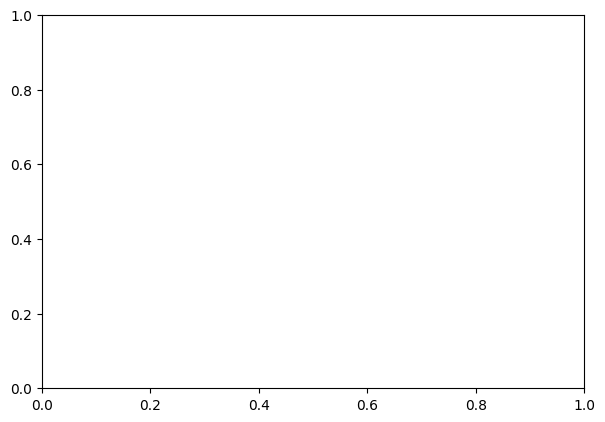

In [13]:
fig, ax = plt.subplots(figsize=(7.0, 4.85))

if len(aggregated_rows) == 0:
    raise RuntimeError(
        "No aggregated rows found for current CONFIG_TAG. "
        "Run the aggregation cell first or check config/data cache."
    )

for n in N_QUBITS_LIST[:-3]: # Except last 3 elements
    xs, ys, yerr = [], [], []
    for N in N_SHOTS_LIST:
        rec = next((r for r in aggregated_rows if int(r["n_qubits"]) == n and int(r["n_shots"]) == N), None)
        if rec is None:
            raise RuntimeError(f"Missing aggregated record for n={n}, N={N}")
        if np.isnan(float(rec["tvd_mean"])):
            raise RuntimeError(
                f"TVD mean is NaN for n={n}, N={N}. "
                "This usually means single-path rows are missing for current CONFIG_TAG."
            )
        xs.append(N)
        ys.append(float(rec["tvd_mean"]))
        yerr.append(float(rec["tvd_std"]))
    ax.errorbar(xs, ys, yerr=yerr, marker="o", linewidth=3, markersize=7, capsize=4, label=f"n={n}")

font_size_tick = 23
font_size_label = 23
ax.tick_params(axis='both', which='major', labelsize=font_size_tick)
ax.set_xscale("log", base=2)
ax.set_xticks(N_SHOTS_LIST)
ax.get_xaxis().set_major_formatter(mticker.ScalarFormatter())
ax.set_xlabel("Number of runs", fontsize=font_size_label)
ax.set_ylabel("TVD to exp. path dist.", fontsize=font_size_label)
# ax.set_title("GHZ dynamic family: single-path convergence to all-branches")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=22)
fig.tight_layout()

out_tvd = FIG_DIR / "ghz_single_vs_all_tvd_vs_nshots.pgf"
fig.savefig(out_tvd, format="pgf", bbox_inches="tight")
log(f"Saved plot: {out_tvd}")



## Test B Plots: Runtime and Peak Memory vs Qubit Count

StopIteration: 

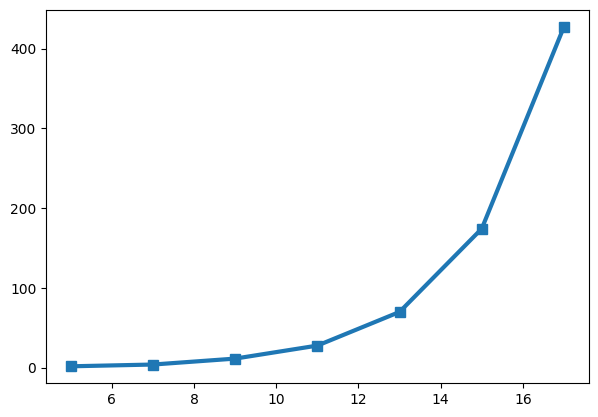

In [14]:
# Runtime scaling
fig_rt, ax_rt = plt.subplots(figsize=(7.0, 4.85))

x_or = [int(row["n_qubits"]) for row in all_branches_rows]
y_or = [float(row["runtime_sec"]) for row in all_branches_rows]
ax_rt.plot(x_or, y_or, marker="s", linewidth=3.0, markersize=7, label="multi-path (no pruning)")

# x_or, y_or = [], []
# for n in N_QUBITS_LIST:
#     rec = next(
#         (r for r in pruning_rows
#          if int(r["n_qubits"]) == n
#          and int(r["max_branches"]) == 64
#          and abs(float(r["probability_cutoff"]) - 0.0) < 1e-15),
#         None,
#     )
#     if rec is not None:
#         x_or.append(n)
#         y_or.append(float(rec["runtime_sec"]))

# ax_rt.plot(x_or, y_or, marker="s", linewidth=3.0, markersize=7, label="multi-path (max_branches=64)")


for N in COST_SHOT_SUBSET:
    xs, ys, yerr = [], [], []
    for n in N_QUBITS_LIST:
        rec = next(r for r in aggregated_rows if int(r["n_qubits"]) == n and int(r["n_shots"]) == N)
        xs.append(n)
        ys.append(float(rec["runtime_sec_mean"]))
        yerr.append(float(rec["runtime_sec_std"]))
    ax_rt.errorbar(xs, ys, yerr=yerr, marker="o", linewidth=3.0, markersize=7, capsize=4, label=f"single-path (runs={N})")

font_size_tick = 23
font_size_label = 23
ax_rt.tick_params(axis='both', which='major', labelsize=font_size_tick)
ax_rt.set_xlabel("Number of qubits", fontsize=font_size_label)
ax_rt.set_ylabel("Runtime (seconds)", fontsize=font_size_label)
ax_rt.set_xticks(N_QUBITS_LIST)
# ax_rt.set_title("GHZ dynamic family: runtime scaling")
ax_rt.grid(True, alpha=0.3)
ax_rt.legend(fontsize=22)
fig_rt.tight_layout()
out_rt = FIG_DIR / "ghz_runtime_vs_qubits.pgf"
fig_rt.savefig(out_rt, format="pgf", bbox_inches="tight")
log(f"Saved plot: {out_rt}")

# Peak memory scaling
fig_mem, ax_mem = plt.subplots(figsize=(7.0, 4.85))

x_or = [int(row["n_qubits"]) for row in all_branches_rows]
y_or = [float(row["peak_bytes"]) / (1024.0**2) for row in all_branches_rows]
ax_mem.plot(x_or, y_or, marker="s", linewidth=3.0, markersize=7, label="multi-path (no pruning)")

for N in COST_SHOT_SUBSET[:1]:
    xs, ys, yerr = [], [], []
    for n in N_QUBITS_LIST:
        rec = next(r for r in aggregated_rows if int(r["n_qubits"]) == n and int(r["n_shots"]) == N)
        xs.append(n)
        ys.append(float(rec["peak_bytes_mean"]) / (1024.0**2))
        yerr.append(float(rec["peak_bytes_std"]) / (1024.0**2))
    ax_mem.errorbar(xs, ys, marker="o", linewidth=3.0, markersize=7, capsize=4, label=f"single-path")

ax_mem.tick_params(axis='both', which='major', labelsize=font_size_tick)
ax_mem.set_xlabel("Number of qubits", fontsize=font_size_label)
ax_mem.set_xticks(N_QUBITS_LIST)
ax_mem.set_ylabel("Peak memory (MB)", fontsize=font_size_label)
# ax_mem.set_title("GHZ dynamic family: peak-memory scaling")
ax_mem.grid(True, alpha=0.3)
ax_mem.legend(fontsize=22)
fig_mem.tight_layout()
out_mem = FIG_DIR / "ghz_peak_memory_vs_qubits.pgf"
fig_mem.savefig(out_mem, format="pgf", bbox_inches="tight")
log(f"Saved plot: {out_mem}")

## Test C Plots: Pruning Tradeoff

[03:47:42] Saved plot: /Users/innocenzo/Desktop/Work/Quantum-Circuit-Simulator-DMRG/notebooks_for_paper/figures/ghz_pruning_tvd_vs_maxbranches.pgf
[03:47:43] Saved plot: /Users/innocenzo/Desktop/Work/Quantum-Circuit-Simulator-DMRG/notebooks_for_paper/figures/ghz_pruning_pareto_runtime_tvd.pgf


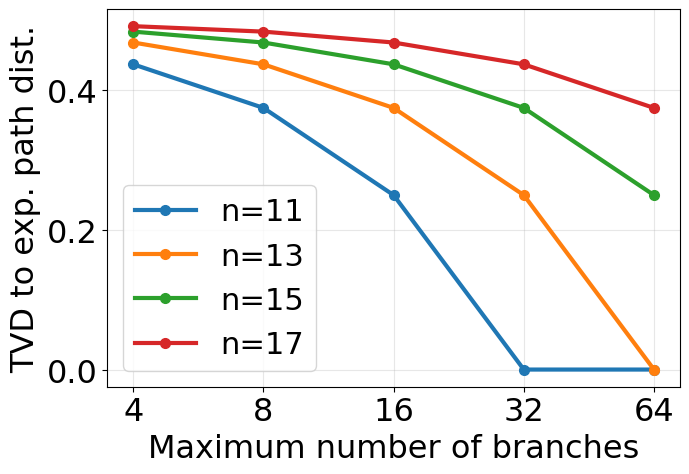

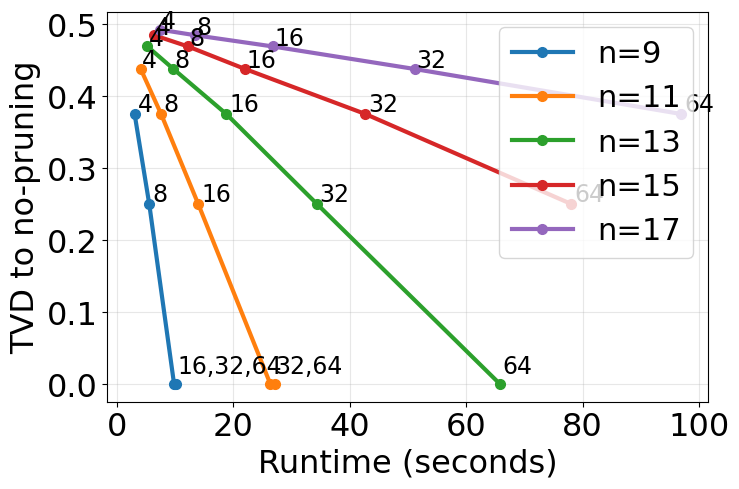

In [63]:
# TVD vs max_branches (one curve per qubit count)
fig_c1, ax_c1 = plt.subplots(figsize=(7.0, 4.85))

for n in N_QUBITS_LIST[3:]:
    xs, ys = [], []
    for mb in PRUNING_MAX_BRANCHES:
        rec = next(
            (r for r in pruning_rows if int(r["n_qubits"]) == n and int(r["max_branches"]) == mb and abs(float(r["probability_cutoff"]) - 0.0) < 1e-15),
            None,
        )
        if rec is not None:
            xs.append(mb)
            ys.append(float(rec["tvd_to_oracle"]))
    ax_c1.plot(xs, ys, marker="o", linewidth=3.0, markersize=7, label=f"n={n}")

font_size_tick = 23
font_size_label = 23
ax_c1.tick_params(axis='both', which='major', labelsize=font_size_tick)

ax_c1.set_xscale("log", base=2)
ax_c1.set_xticks(PRUNING_MAX_BRANCHES)
ax_c1.get_xaxis().set_major_formatter(mticker.ScalarFormatter())
ax_c1.set_xlabel("Maximum number of branches", fontsize=font_size_label)
ax_c1.set_ylabel("TVD to exp. path dist.", fontsize=font_size_label)
# ax_c1.set_title("GHZ dynamic family: TVD vs max_branches", fontsize=font_size_label)
ax_c1.grid(True, which="both", alpha=0.3)
ax_c1.legend(fontsize=22)
fig_c1.tight_layout()
out_c1 = FIG_DIR / "ghz_pruning_tvd_vs_maxbranches.pgf"
fig_c1.savefig(out_c1, format="pgf", bbox_inches="tight")
log(f"Saved plot: {out_c1}")

from collections import defaultdict
def annotate_grouped_labels(ax, grouped_points, dx=2, dy=2, fontsize=13, x_tol=4.0, y_tol=0.02):
    bottom_points = []
    other_points = []

    # separa i punti vicini all'asse x dagli altri
    for x, y, label in grouped_points:
        if abs(y) <= y_tol:
            bottom_points.append((x, y, label))
        else:
            other_points.append((x, y, label))

    # 1) etichette normali: più vicine ai marker
    for x, y, label in other_points:
        local_dx, local_dy = dx, dy

        # per i punti in alto a sinistra tienile ancora più vicine
        if y > 0.43:
            local_dx, local_dy = 1, 1

        ax.annotate(
            str(label),
            (x, y),
            xytext=(local_dx, local_dy),
            textcoords="offset points",
            fontsize=fontsize,
        )

    # 2) punti in basso: raggruppa quelli vicini e unisci le label con virgola
    clusters = []
    for x, y, label in bottom_points:
        assigned = False
        for cluster in clusters:
            cx, cy, labels = cluster
            if abs(x - cx) <= x_tol and abs(y - cy) <= y_tol:
                labels.append((x, y, label))
                assigned = True
                break
        if not assigned:
            clusters.append([x, y, [(x, y, label)]])

    for _, _, pts in clusters:
        xs = [x for x, _, _ in pts]
        ys = [y for _, y, _ in pts]
        labels = sorted(label for _, _, label in pts)

        x_anchor = sum(xs) / len(xs)
        y_anchor = sum(ys) / len(ys)
        text = ",".join(str(lbl) for lbl in labels)

        ax.annotate(
            text,
            (x_anchor, y_anchor),
            xytext=(2, 8),
            textcoords="offset points",
            fontsize=fontsize,
        )
    
fig_c2, ax_c2 = plt.subplots(figsize=(7.5, 5))
all_grouped_points = []

for n in N_QUBITS_LIST[2:]:
    xs, ys = [], []
    grouped_points = []
    for mb in PRUNING_MAX_BRANCHES:
        rec = next(
            (r for r in pruning_rows
             if int(r["n_qubits"]) == n
             and int(r["max_branches"]) == mb
             and abs(float(r["probability_cutoff"]) - 0.0) < 1e-15),
            None,
        )
        if rec is not None:
            x = float(rec["runtime_sec"])
            y = float(rec["tvd_to_oracle"])
            xs.append(x)
            ys.append(y)
            grouped_points.append((x, y, mb))

    if len(xs) > 0:
        ax_c2.plot(xs, ys, marker="o", linewidth=3.0, markersize=7, label=f"n={n}")
        all_grouped_points.extend(grouped_points)

annotate_grouped_labels(
    ax_c2,
    all_grouped_points,
    dx=2,
    dy=2,
    fontsize=17,
    x_tol=4.0,
    y_tol=0.02,
)

ax_c2.tick_params(axis='both', which='major', labelsize=font_size_tick)
ax_c2.set_xlabel("Runtime (seconds)", fontsize=font_size_label)
ax_c2.set_ylabel("TVD to no-pruning", fontsize=font_size_label)
ax_c2.grid(True, alpha=0.3)
ax_c2.legend(fontsize=22)
fig_c2.tight_layout()
out_c2 = FIG_DIR / "ghz_pruning_pareto_runtime_tvd.pgf"
fig_c2.savefig(out_c2, format="pgf", bbox_inches="tight")
log(f"Saved plot: {out_c2}")

# OLD
# def annotate_grouped_labels(ax, grouped_points, x_round=2, y_round=6, dx=4, dy=4, fontsize=8):
#     buckets = {}
#     for x, y, lab in grouped_points:
#         key = (round(float(x), x_round), round(float(y), y_round))
#         if key not in buckets:
#             buckets[key] = {"x": float(x), "y": float(y), "labels": []}
#         buckets[key]["labels"].append(int(lab))

#     for item in buckets.values():
#         labels_sorted = sorted(set(item["labels"]))
#         text = ",".join(str(v) for v in labels_sorted)
#         ax.annotate(text, (item["x"], item["y"]), textcoords="offset points", xytext=(dx, dy), fontsize=fontsize)


# # Pareto-like: TVD vs runtime
# fig_c2, ax_c2 = plt.subplots(figsize=(7.5, 5))
# for n in N_QUBITS_LIST[2:]:
#     xs, ys = [], []
#     grouped_points = []
#     for mb in PRUNING_MAX_BRANCHES:
#         rec = next(
#             (r for r in pruning_rows if int(r["n_qubits"]) == n and int(r["max_branches"]) == mb and abs(float(r["probability_cutoff"]) - 0.0) < 1e-15),
#             None,
#         )
#         if rec is not None:
#             x = float(rec["runtime_sec"])
#             y = float(rec["tvd_to_oracle"])
#             xs.append(x)
#             ys.append(y)
#             grouped_points.append((x, y, mb))
#     if len(xs) > 0:
#         ax_c2.plot(xs, ys, marker="o", linewidth=3.0, markersize=7, label=f"n={n}")
#         annotate_grouped_labels(ax_c2, grouped_points, x_round=2, y_round=6, dx=4, dy=4, fontsize=13)

# ax_c2.tick_params(axis='both', which='major', labelsize=font_size_tick)
# ax_c2.set_xlabel("Runtime (seconds)", fontsize=font_size_label)
# ax_c2.set_ylabel("TVD to no-pruning", fontsize=font_size_label)
# # ax_c2.set_title("GHZ dynamic family: pruning Pareto (runtime vs TVD)")
# ax_c2.grid(True, alpha=0.3)
# ax_c2.legend(fontsize=17)
# fig_c2.tight_layout()
# out_c2 = FIG_DIR / "ghz_pruning_pareto_runtime_tvd.pgf"
# fig_c2.savefig(out_c2, format="pgf", bbox_inches="tight")
# log(f"Saved plot: {out_c2}")






# # Pruning-error bound vs max_branches (one curve per qubit count)
# fig_c3, ax_c3 = plt.subplots(figsize=(7.0, 4.6))

# for n in N_QUBITS_LIST:
#     xs, ys = [], []
#     for mb in PRUNING_MAX_BRANCHES:
#         rec = next(
#             (r for r in pruning_rows if int(r["n_qubits"]) == n and int(r["max_branches"]) == mb and abs(float(r["probability_cutoff"]) - 0.0) < 1e-15),
#             None,
#         )
#         if rec is not None:
#             xs.append(mb)
#             ys.append(float(rec["pruning_error_bound"]))
#     ax_c3.plot(xs, ys, marker="o", linewidth=1.8, label=f"n={n}")

# ax_c3.set_xscale("log", base=2)
# ax_c3.set_xticks(PRUNING_MAX_BRANCHES)
# ax_c3.get_xaxis().set_major_formatter(mticker.ScalarFormatter())
# ax_c3.set_xlabel("max_branches")
# ax_c3.set_ylabel("Pruning error bound")
# ax_c3.set_title("GHZ dynamic family: pruning error bound vs max_branches")
# ax_c3.grid(True, which="both", alpha=0.3)
# ax_c3.legend()
# fig_c3.tight_layout()
# out_c3 = FIG_DIR / "ghz_pruning_error_bound_vs_maxbranches.pgf"
# fig_c3.savefig(out_c3, format="pgf", bbox_inches="tight")
# log(f"Saved plot: {out_c3}")

# # Pareto-like: pruning-error bound vs runtime
# fig_c4, ax_c4 = plt.subplots(figsize=(7.0, 4.6))
# for n in N_QUBITS_LIST:
#     xs, ys = [], []
#     grouped_points = []
#     for mb in PRUNING_MAX_BRANCHES:
#         rec = next(
#             (r for r in pruning_rows if int(r["n_qubits"]) == n and int(r["max_branches"]) == mb and abs(float(r["probability_cutoff"]) - 0.0) < 1e-15),
#             None,
#         )
#         if rec is not None:
#             x = float(rec["runtime_sec"])
#             y = float(rec["pruning_error_bound"])
#             xs.append(x)
#             ys.append(y)
#             grouped_points.append((x, y, mb))
#     if len(xs) > 0:
#         ax_c4.plot(xs, ys, marker="o", linewidth=1.6, label=f"n={n}")
#         annotate_grouped_labels(ax_c4, grouped_points, x_round=2, y_round=8, dx=4, dy=4, fontsize=8)

# ax_c4.set_xlabel("Runtime (seconds)")
# ax_c4.set_ylabel("Pruning error bound")
# ax_c4.set_title("GHZ dynamic family: pruning Pareto (runtime vs pruning error bound)")
# ax_c4.grid(True, alpha=0.3)
# ax_c4.legend()
# fig_c4.tight_layout()
# out_c4 = FIG_DIR / "ghz_pruning_pareto_runtime_error_bound.pgf"
# fig_c4.savefig(out_c4, format="pgf", bbox_inches="tight")
# log(f"Saved plot: {out_c4}")

## Compact Console Summary

In [ ]:
print("All-branches oracle summary:")
print("n | expected_branches | recovered_branches | fidelity | runtime[s] | peak[MiB]")
for row in sorted(all_branches_rows, key=lambda x: int(x["n_qubits"])):
    print(
        f"{int(row['n_qubits']):2d} | {int(row['num_expected_branches']):16d} | {int(row['num_recovered_branches']):17d} | "
        f"{float(row['fidelity']):.6f} | {float(row['runtime_sec']):.4f} | {float(row['peak_bytes'])/(1024.0**2):.3f}"
    )

print("Single-path TVD summary (mean ± std):")
print("n | N | TVD")
for n in N_QUBITS_LIST:
    for N in N_SHOTS_LIST:
        rec = next(r for r in aggregated_rows if int(r["n_qubits"]) == n and int(r["n_shots"]) == N)
        print(f"{n:2d} | {N:2d} | {float(rec['tvd_mean']):.6f} ± {float(rec['tvd_std']):.6f}")

print("Pruning summary (cutoff=0):")
print("n | max_branches | TVD | runtime[s] | peak[MiB] | pruning_error_bound")
for n in N_QUBITS_LIST:
    rows_n = sorted(
        [r for r in pruning_rows if int(r["n_qubits"]) == n and abs(float(r["probability_cutoff"]) - 0.0) < 1e-15],
        key=lambda x: int(x["max_branches"]),
    )
    for r in rows_n:
        print(
            f"{n:2d} | {int(r['max_branches']):11d} | {float(r['tvd_to_oracle']):.6f} | {float(r['runtime_sec']):.4f} | "
            f"{float(r['peak_bytes'])/(1024.0**2):.3f} | {float(r['pruning_error_bound']):.3e}"
        )

print("Data files written in:", DATA_DIR)
print("Figures written in:", FIG_DIR)

All-branches oracle summary:
n | expected_branches | recovered_branches | fidelity | runtime[s] | peak[MiB]
 7 |                8 |                 8 | 1.000000 | 4.2021 | 0.012
11 |               32 |                32 | 1.000000 | 25.3172 | 0.078
15 |              128 |               128 | 1.000000 | 156.2513 | 0.438
Single-path TVD summary (mean ± std):
n | N | TVD
 7 |  1 | 0.875000 ± 0.000000
 7 |  2 | 0.775000 ± 0.055902
 7 |  4 | 0.625000 ± 0.125000
 7 |  8 | 0.375000 ± 0.088388
 7 | 16 | 0.200000 ± 0.102698
 7 | 32 | 0.181250 ± 0.040745
 7 | 64 | 0.118750 ± 0.032401
11 |  1 | 0.968750 ± 0.000000
11 |  2 | 0.937500 ± 0.000000
11 |  4 | 0.875000 ± 0.000000
11 |  8 | 0.775000 ± 0.026146
11 | 16 | 0.600000 ± 0.040745
11 | 32 | 0.368750 ± 0.026146
11 | 64 | 0.275000 ± 0.042216
15 |  1 | 0.992187 ± 0.000000
15 |  2 | 0.985937 ± 0.003494
15 |  4 | 0.968750 ± 0.000000
15 |  8 | 0.937500 ± 0.000000
15 | 16 | 0.879687 ± 0.004279
15 | 32 | 0.773438 ± 0.012353
15 | 64 | 0.606250 ± 0.021108

: 

: 

: 

In [1]:
# Sanity check: GHZ output from DMRG_dynamic_single_path_from_circuit_ir
sanity_n = 7
sanity_seed = 20260417
sanity_compression_steps = COMPRESSION_STEPS if "COMPRESSION_STEPS" in globals() else 25
sanity_no_sweeps = NO_SWEEPS if "NO_SWEEPS" in globals() else 2
sanity_network_type = NETWORK_TYPE if "NETWORK_TYPE" in globals() else "mps"
sanity_bond_dim = BOND_DIM if "BOND_DIM" in globals() else 2

# MPS
qc_sanity = create_constant_depth_dynamic_ghz(sanity_n, final_measure_all=False)
ir_sanity = circuit_to_dynamic_ir(qc_sanity)
D_sanity = mps_dims(sanity_n, sanity_bond_dim)

# # TTN
# sanity_network_type = "tree"
sanity_structure = [1, sanity_n]              # TTN a stella (radice + 7 foglie)
# D_sanity = [sanity_bond_dim] * (len(sanity_structure) - 1)   # -> [bond_dim]

single_fidelity, single_branch_prob, single_classical_bits, single_state, single_memory = DMRG_dynamic_single_path_from_circuit_ir(
    compression_steps=sanity_compression_steps,
    no_sweeps=sanity_no_sweeps,
    D=D_sanity,
    network_structure=sanity_structure,
    circuit_ir=ir_sanity,
    network_type="mps",
    seed=sanity_seed,
    return_state=True,
    return_bra=False,
    return_classical_bits=True,
    return_branch_probability=True,
    n_samples_final=None,
    return_counts=False,
    return_shots=False,
    return_memory_stats=True,
)

single_state = np.asarray(single_state, dtype=complex).reshape(-1)
tol = 1e-10
nz = [
    (format(i, f"0{sanity_n}b"), single_state[i])
    for i in range(single_state.size)
    if abs(single_state[i]) > tol
]

print("SINGLE-PATH OUTPUT")
print(f"n_qubits: {sanity_n}")
print(f"seed: {sanity_seed}")
print(f"fidelity: {single_fidelity:.12f}")
print(f"sampled branch probability: {single_branch_prob:.12f}")
print(f"classical bits: {single_classical_bits.tolist()}")
print(f"peak memory [bytes]: {single_memory['peak_bytes_estimate']}")
print(f"final memory [bytes]: {single_memory['final_bytes_estimate']}")
print("non-zero amplitudes (bitstring -> amplitude):")
for bitstr, amp in nz:
    print(f"  {bitstr} -> {amp}")
print("full state vector:")
print(np.array2string(single_state, precision=6, suppress_small=True, max_line_width=140))



NameError: name 'create_constant_depth_dynamic_ghz' is not defined

In [55]:
def create_constant_depth_dynamic_ghz_local(n_qubits: int, final_measure_all: bool = False) -> QuantumCircuit:
    """
    Build the dynamic constant-depth GHZ-style circuit.

    Pattern:
    1) H on even qubits
    2) CNOT fan-out from even qubits
    3) Mid-circuit measurements on odd qubits
    4) Conditional X corrections based on measurement logic
    5) Reset odd qubits
    6) Final CNOT layer
    7) Optional final measurements of all qubits
    """
    assert n_qubits >= 5 and n_qubits % 2 == 1, "n_qubits must be odd and >= 5"

    qr = QuantumRegister(n_qubits, "q")
    cr_branch = ClassicalRegister((n_qubits - 1) // 2, "cr1")

    if final_measure_all:
        cr_out = ClassicalRegister(n_qubits, "meas")
        qc = QuantumCircuit(qr, cr_branch, cr_out)
    else:
        qc = QuantumCircuit(qr, cr_branch)

    # Layer 1: H on even qubits
    for i in range(0, n_qubits, 2):
        qc.h(i)

    # Layer 2: CNOT fan-out from even qubits to neighbors
    for i in range(0, n_qubits - 1, 2):
        qc.cx(i, i + 1)
        if i > 0:
            qc.cx(i, i - 1)
    qc.cx(n_qubits - 1, n_qubits - 2)

    # Layer 3: measure odd qubits into branch register
    for i in range(1, n_qubits, 2):
        qc.measure(i, cr_branch[i // 2])

    # Layer 4: conditional corrections
    with qc.if_test((cr_branch[0], 1)):
        qc.x(2)

    for i in range(3, n_qubits - 1, 2):
        xor_expr = expr.lift(cr_branch[0])
        for j in range(1, i // 2 + 1):
            xor_expr = expr.bit_xor(cr_branch[j], xor_expr)
        with qc.if_test(xor_expr):
            qc.x(i + 1)

    # Layer 5: reset measured odd qubits
    for i in range(1, n_qubits, 2):
        qc.reset(i)

    # # Layer 6: re-entangle odd qubits after reset
    # for i in range(0, n_qubits - 1, 2):
    #     qc.cx(i, i + 1)

    # # Layer 7: optional final readout
    # if final_measure_all:
    #     for i in range(n_qubits):
    #         qc.measure(i, cr_out[i])

    return qc



# Sanity check: GHZ output from DMRG_dynamic_all_branches_from_circuit_ir (max-branches mode)
sanity_n = 7
sanity_max_branches = 4
sanity_cutoff = 0.0
sanity_compression_steps = COMPRESSION_STEPS if "COMPRESSION_STEPS" in globals() else 25
sanity_no_sweeps = NO_SWEEPS if "NO_SWEEPS" in globals() else 2
sanity_network_type = NETWORK_TYPE if "NETWORK_TYPE" in globals() else "mps"
sanity_bond_dim = BOND_DIM if "BOND_DIM" in globals() else 2

qc_sanity = create_constant_depth_dynamic_ghz_local(sanity_n, final_measure_all=False)
ir_sanity = circuit_to_dynamic_ir(qc_sanity)
D_sanity = mps_dims(sanity_n, sanity_bond_dim)

all_fidelity, all_pruning_error, all_branches, all_memory = DMRG_dynamic_all_branches_from_circuit_ir(
    compression_steps=sanity_compression_steps,
    no_sweeps=sanity_no_sweeps,
    D=D_sanity,
    network_structure=[sanity_n],
    circuit_ir=ir_sanity,
    network_type="mps",
    max_branches=sanity_max_branches,
    probability_cutoff=sanity_cutoff,
    max_pruning_error=None,
    return_branches=True,
    return_state=True,
    return_bra=False,
    return_classical_bits=True,
    return_pruning_error=True,
    return_memory_stats=True,
)

m = (sanity_n - 1) // 2
branch_rows = []
for b in all_branches:
    label = bits_to_label(b["classical_bits"], expected_len=m)
    state = np.asarray(b["state"], dtype=complex).reshape(-1)
    nz = [
        (format(i, f"0{sanity_n}b"), state[i])
        for i in range(state.size)
        if abs(state[i]) > 1e-10
    ]
    branch_rows.append((
        label,
        float(b["probability"]),
        float(b["conditional_probability"]),
        float(b["branch_fidelity"]),
        state,
        nz,
    ))
branch_rows = sorted(branch_rows, key=lambda x: x[0])

print("MAX-BRANCHES / ALL-BRANCHES OUTPUT")
print(f"n_qubits: {sanity_n}")
print(f"max_branches: {sanity_max_branches}")
print(f"probability_cutoff: {sanity_cutoff}")
print(f"ensemble fidelity: {all_fidelity:.12f}")
print(f"pruning error bound: {all_pruning_error:.12f}")
print(f"num returned branches: {len(all_branches)}")
print(f"peak memory [bytes]: {all_memory['peak_bytes_estimate']}")
print(f"final memory [bytes]: {all_memory['final_bytes_estimate']}")
print("branches (label, probability, conditional_probability, branch_fidelity):")
for label, p, cp, bf, state, nz in branch_rows:
    print(f"  {label} | {p:.12f} | {cp:.12f} | {bf:.12f}")
    print("    non-zero amplitudes:")
    for bitstr, amp in nz:
        print(f"      {bitstr} -> {amp}")

if len(branch_rows) > 0:
    print("full state vector of first returned branch:")
    print(np.array2string(branch_rows[0][4], precision=6, suppress_small=True, max_line_width=140))



MAX-BRANCHES / ALL-BRANCHES OUTPUT
n_qubits: 7
max_branches: 4
probability_cutoff: 0.0
ensemble fidelity: 1.000000000000
pruning error bound: 0.500000000000
num returned branches: 4
peak memory [bytes]: 12288
final memory [bytes]: 6144
branches (label, probability, conditional_probability, branch_fidelity):
  000 | 0.125000000000 | 0.250000000000 | 1.000000000000
    non-zero amplitudes:
      0000000 -> (0.7071067818936543-1.202081513443086e-09j)
      0000001 -> (2.1213203420747194e-10-2.1213203525398988e-10j)
      0000101 -> (2.1213203420747178e-10-2.121320349428629e-10j)
      0010101 -> (2.1213203420747225e-10-2.1213203478729951e-10j)
      1000000 -> (2.121320342074724e-10-2.121320352964162e-10j)
      1010000 -> (2.1213203420747163e-10-2.1213203494286287e-10j)
      1010100 -> (2.1213203420747194e-10-2.121320344054616e-10j)
      1010101 -> (0.7071067804794406+2.1213203416081683e-10j)
  010 | 0.125000000000 | 0.250000000000 | 1.000000000000
    non-zero amplitudes:
      000000

[09:59:05] [single-path runtime] start n=5
[10:01:20] [single-path runtime] start n=7
[10:04:51] [single-path runtime] start n=9
[10:09:22] [single-path runtime] start n=11
[10:14:57] [single-path runtime] start n=13
[10:21:44] [single-path runtime] start n=15
[10:30:22] [single-path runtime] start n=17
[10:40:41] Saved plot: /Users/innocenzo/Desktop/Work/Quantum-Circuit-Simulator-DMRG/notebooks_for_paper/figures/ghz_runtime_vs_qubits_single_256seeds.pgf


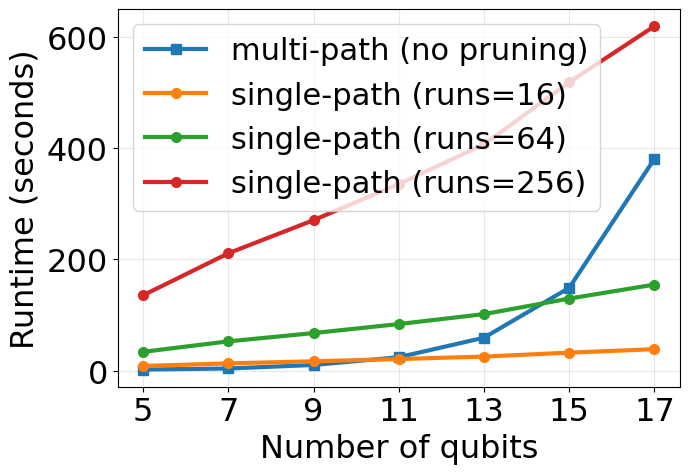

In [73]:
# Runtime scaling: single-path con 256 seed diversi + confronto con multi-path (no pruning)
import time
import numpy as np
import matplotlib.pyplot as plt

SINGLE_TOTAL_RUNS = 256
SINGLE_RUNTIME_SUBSETS = [16, 64, 256]
assert max(SINGLE_RUNTIME_SUBSETS) <= SINGLE_TOTAL_RUNS

_log = log if "log" in globals() else print

# Fallback: costruisci IR se non presenti
if ("ir_by_n" not in globals()) or (len(ir_by_n) == 0):
    circuits = {}
    ir_by_n = {}
    for n in N_QUBITS_LIST:
        qc = create_constant_depth_dynamic_ghz(n, final_measure_all=FINAL_MEASURE_ALL)
        circuits[n] = qc
        ir_by_n[n] = circuit_to_dynamic_ir(qc)

# Fallback: carica oracle rows (multi-path no pruning) se non presenti
if ("all_branches_rows" not in globals()) or (len(all_branches_rows) == 0):
    oracle_csv = DATA_DIR / "ghz_all_branches_oracle.csv"
    all_branches_rows = [r for r in read_csv_rows(oracle_csv) if r.get("config_tag") == CONFIG_TAG]
    for r in all_branches_rows:
        r["n_qubits"] = int(r["n_qubits"])
        r["runtime_sec"] = float(r["runtime_sec"])

single_runtime_stats = {N: {"x": [], "y": [], "yerr": []} for N in SINGLE_RUNTIME_SUBSETS}

for n in N_QUBITS_LIST:
    _log(f"[single-path runtime] start n={n}")
    ir = ir_by_n[n]
    D_n = mps_dims(n, BOND_DIM)

    # 256 seed deterministici e diversi per ogni n
    seed_rng = np.random.default_rng(RANDOM_SEED_BASE + 100000 + n)
    seeds = [int(seed_rng.integers(0, 2**32 - 1, dtype=np.uint32)) for _ in range(SINGLE_TOTAL_RUNS)]

    runtimes = []
    for seed in seeds:
        t0 = time.perf_counter()
        _ = DMRG_dynamic_single_path_from_circuit_ir(
            compression_steps=COMPRESSION_STEPS,
            no_sweeps=NO_SWEEPS,
            D=D_n,
            network_structure=[n],
            circuit_ir=ir,
            network_type=NETWORK_TYPE,
            seed=seed,
            return_state=False,
            return_bra=False,
            return_classical_bits=False,
            return_branch_probability=False,
            n_samples_final=None,
            return_counts=False,
            return_shots=False,
            return_memory_stats=False,
        )
        runtimes.append(time.perf_counter() - t0)

    runtimes = np.asarray(runtimes, dtype=float)

    # Da questi 256 run ricavo metriche "runs=16", "runs=64", "runs=256"
    # usando blocchi disgiunti (mean +- std dei tempi totali per blocco).
    for N in SINGLE_RUNTIME_SUBSETS:
        n_blocks = SINGLE_TOTAL_RUNS // N
        block_totals = np.array(
            [np.sum(runtimes[i * N:(i + 1) * N]) for i in range(n_blocks)],
            dtype=float
        )

        single_runtime_stats[N]["x"].append(n)
        single_runtime_stats[N]["y"].append(float(np.mean(block_totals)))
        single_runtime_stats[N]["yerr"].append(
            float(np.std(block_totals, ddof=1)) if len(block_totals) > 1 else 0.0
        )


[10:42:30] Saved plot: /Users/innocenzo/Desktop/Work/Quantum-Circuit-Simulator-DMRG/notebooks_for_paper/figures/ghz_runtime_vs_qubits_single_256seeds.pgf


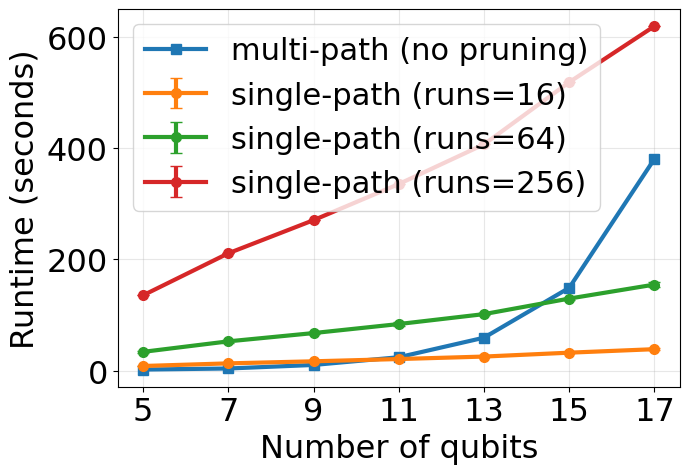

In [75]:

# Plot runtime (stesso stile)
fig_rt, ax_rt = plt.subplots(figsize=(7.0, 4.85))

oracle_map = {int(r["n_qubits"]): float(r["runtime_sec"]) for r in all_branches_rows}
x_or = [n for n in N_QUBITS_LIST if n in oracle_map]
y_or = [oracle_map[n] for n in x_or]
ax_rt.plot(x_or, y_or, marker="s", linewidth=3.0, markersize=7, label="multi-path (no pruning)")

for N in [16, 64, 256]:
    xs = single_runtime_stats[N]["x"]
    ys = single_runtime_stats[N]["y"]
    yerr = single_runtime_stats[N]["yerr"]
    ax_rt.errorbar(
        xs, ys, yerr=yerr,
        marker="o", linewidth=3.0, markersize=7, capsize=4,
        label=f"single-path (runs={N})"
    )

font_size_tick = 23
font_size_label = 23
ax_rt.tick_params(axis="both", which="major", labelsize=font_size_tick)
ax_rt.set_xlabel("Number of qubits", fontsize=font_size_label)
ax_rt.set_ylabel("Runtime (seconds)", fontsize=font_size_label)
ax_rt.set_xticks(N_QUBITS_LIST)
ax_rt.grid(True, alpha=0.3)
ax_rt.legend(fontsize=22)
fig_rt.tight_layout()

out_rt = FIG_DIR / "ghz_runtime_vs_qubits_single_256seeds.pgf"
fig_rt.savefig(out_rt, format="pgf", bbox_inches="tight")
_log(f"Saved plot: {out_rt}")